In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [61]:
df = pd.read_csv("hotel_bookings.csv")

In [62]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [63]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [64]:
df.shape

(119390, 32)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [66]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [67]:
# checking for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [68]:
# replacing 'children' missing values with 0
df['children'].fillna(0,inplace=True)

C:\Users\charl\AppData\Local\Temp\ipykernel_18364\620959694.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['children'].fillna(0,inplace=True)


In [69]:
# changing 'country' missing values for unknown
df['country'].fillna('Unknown',inplace=True)

C:\Users\charl\AppData\Local\Temp\ipykernel_18364\3368286714.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown',inplace=True)


In [70]:
# dropping two columns that present high missing values and are not meaninfull for our model training
df.drop(columns=['company', 'agent'], inplace=True)

In [71]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

### _PCA_

In [72]:
# In order to do the PCA we created a new variable named cleaned_dataset
cleaned_dataset = df.copy()

In [108]:
cleaned_dataset.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [109]:
cleaned_dataset.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [110]:
cleaned_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 30 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [117]:
# Making a copy to avoid overwriting original
df_encoded = cleaned_dataset.copy()

# Identifying categorical columns
categorical_cols = df_encoded.select_dtypes(include='object').columns

# Initializing encoder
le = LabelEncoder()

# Applying label encoding to each categorical column
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    
# Dropping rows with missing values for simplicity (you can use imputation instead)
df_encoded = df_encoded.dropna()

# # Separating features and target
# X = df_encoded.drop(columns=['is_canceled'])  # features
# y = df_encoded['is_canceled']  # target (for coloring the plot only)

# # Standardizing the features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Applying PCA to reduce to 2 components
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

# # Creating DataFrame with PCA results and original label
# pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
# pca_df['is_canceled'] = y.values

# # Plotting PCA result
# plt.figure(figsize=(12, 6))
# sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='is_canceled', palette='Set1', alpha=0.6)
# plt.title('PCA of Hotel Bookings (2 Components)', fontsize=14, weight='bold')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.legend(title='Canceled')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# # Viewing the result
# df_encoded.info()

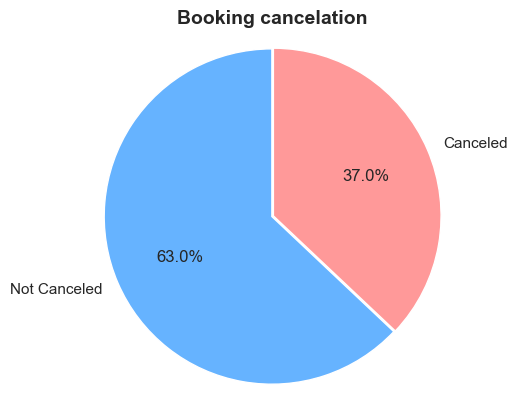

In [74]:
# plot showing proportion between cancelled and not cancelled bookings
cancel_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']
colors = ['#66b3ff', '#ff9999']

plt.pie(cancel_counts, labels = labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0,0.01))
plt.title('Booking cancelation', fontsize=14, weight='bold')
plt.axis('equal')
plt.show()

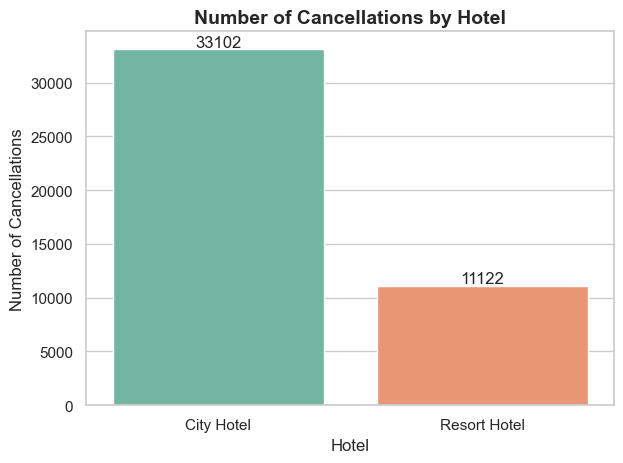

In [75]:
cancel_counts = df[df['is_canceled'] == 1]['hotel'].value_counts()

sns.barplot(x=cancel_counts.index, y=cancel_counts.values, palette='Set2')
plt.title('Number of Cancellations by Hotel', fontsize=14, weight='bold')
plt.ylabel('Number of Cancellations')
plt.xlabel('Hotel')

for i, val in enumerate(cancel_counts.values):
    plt.text(i, val + 200, str(val), ha='center')

plt.tight_layout()
plt.show()

### 📊 _1. No-show Rate vs. Lead Time_

Why: Helps show if longer lead times lead to higher no-show rates.

C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

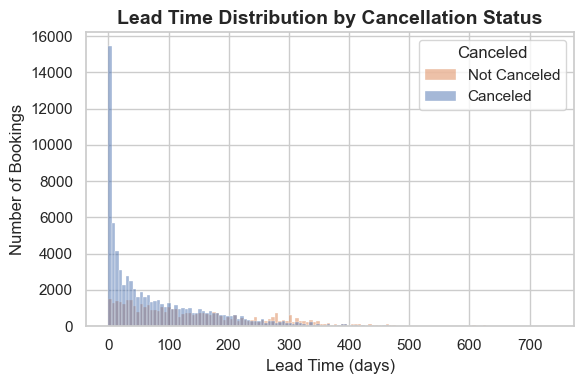

In [76]:
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='lead_time', hue='is_canceled', bins="auto", kde=False, stat='count', common_norm=False)
plt.title('Lead Time Distribution by Cancellation Status', fontsize=14, weight='bold')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.legend(title='Canceled', labels=['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()


### 📆 2. Monthly Booking Trends

Why: Seasonal trends reveal overbooking risk in peak periods.

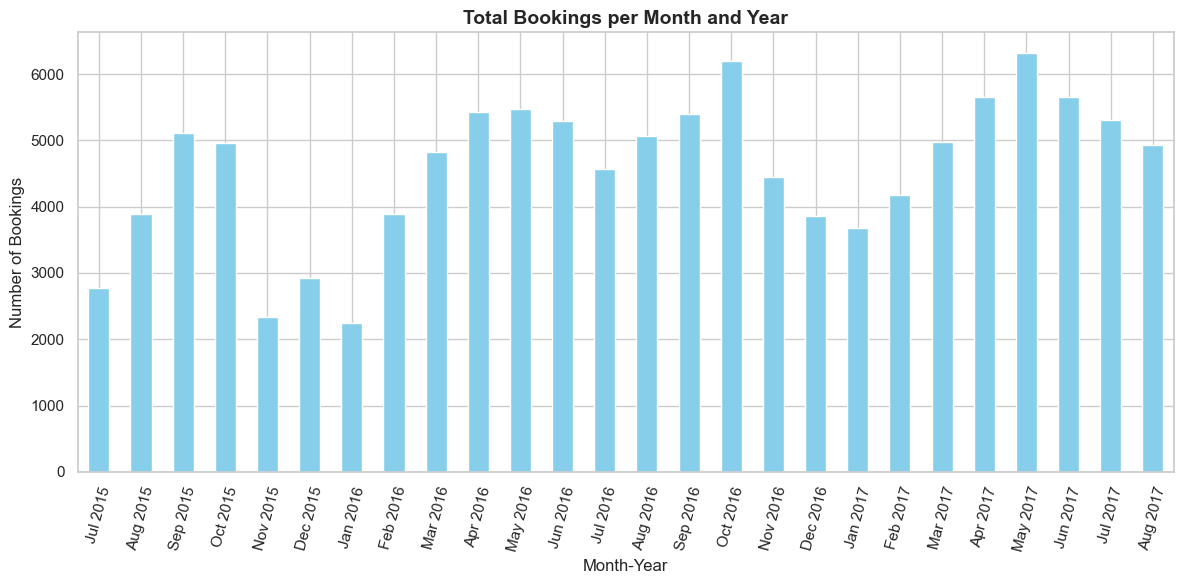

In [77]:
# Combining year and month to create a sortable date index
df['year_month'] = pd.to_datetime(df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'], format='%Y-%B')

# Grouping by year + month
monthly = df.groupby(df['year_month']).size()

# Plotting
monthly.plot(kind='bar', color='skyblue', figsize=(12, 6))
plt.title('Total Bookings per Month and Year', fontsize=14, weight='bold')
plt.ylabel('Number of Bookings')
plt.xlabel('Month-Year')
plt.xticks(ticks=range(len(monthly.index)), labels=monthly.index.strftime('%b %Y'), rotation=75)
plt.tight_layout()
plt.show()


### 🧑‍🤝‍🧑 3. Cancellation Rate by Customer Type

Why: Shows which customer segments are more likely to cancel.

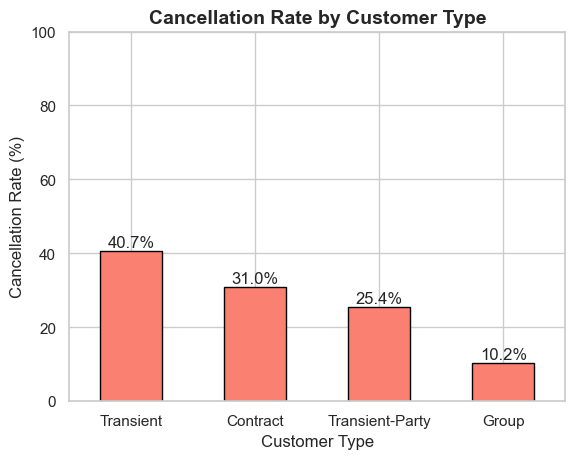

In [78]:
cancel_by_type = df.groupby('customer_type')['is_canceled'].mean() * 100
cancel_by_type = cancel_by_type.sort_values(ascending=False)

cancel_by_type.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Cancellation Rate by Customer Type', fontsize=14, weight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Customer Type')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for index, value in enumerate(cancel_by_type):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


### 🏨 4. ADR by Cancellation

Why: Highlights if price influences cancellations (i.e., high cost → more no-shows?).

C:\Users\charl\AppData\Local\Temp\ipykernel_18364\2645966549.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adr_cancel = df.groupby('adr_range')['is_canceled'].mean() * 100


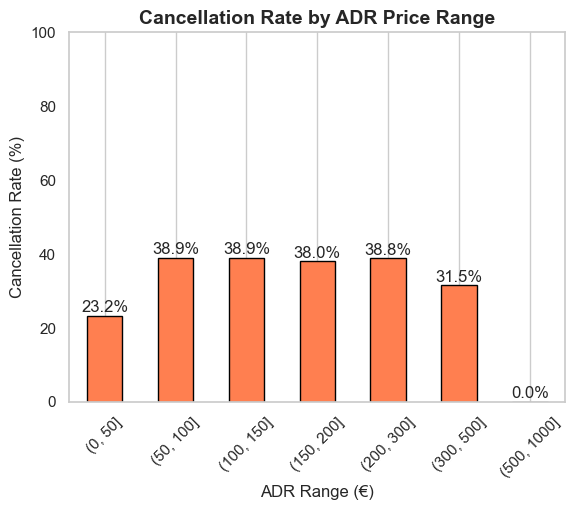

In [79]:
adr_bins = [0, 50, 100, 150, 200, 300, 500, 1000]
df['adr_range'] = pd.cut(df['adr'], bins=adr_bins)

adr_cancel = df.groupby('adr_range')['is_canceled'].mean() * 100
adr_cancel = adr_cancel.sort_index()

adr_cancel.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Cancellation Rate by ADR Price Range', fontsize=14, weight='bold')
plt.xlabel('ADR Range (€)')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)

for index, value in enumerate(adr_cancel):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.grid(axis='y')
plt.show()


### 🌍 5. Top Countries by No-show Rate

Why: Flags specific regions with higher cancellation risk.

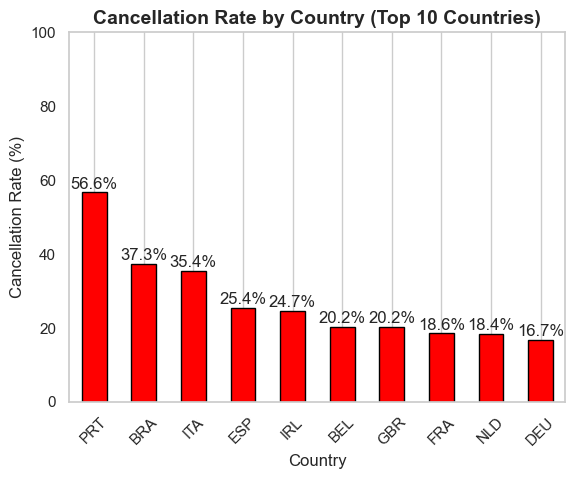

In [80]:
top_countries = df['country'].value_counts().head(10).index

# Calculate cancellation rate and convert to percentage
country_cancel = df[df['country'].isin(top_countries)].groupby('country')['is_canceled'].mean() * 100
country_cancel = country_cancel.sort_values(ascending=False)

# Plot
country_cancel.plot(kind='bar', color='red', edgecolor='black')
plt.title('Cancellation Rate by Country (Top 10 Countries)', fontsize=14, weight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y')

# Show percentage labels on bars
for index, value in enumerate(country_cancel):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


### 🔀 6. Reserved vs Assigned Room Type

Why: Shows whether room assignment mismatches influence no-shows.

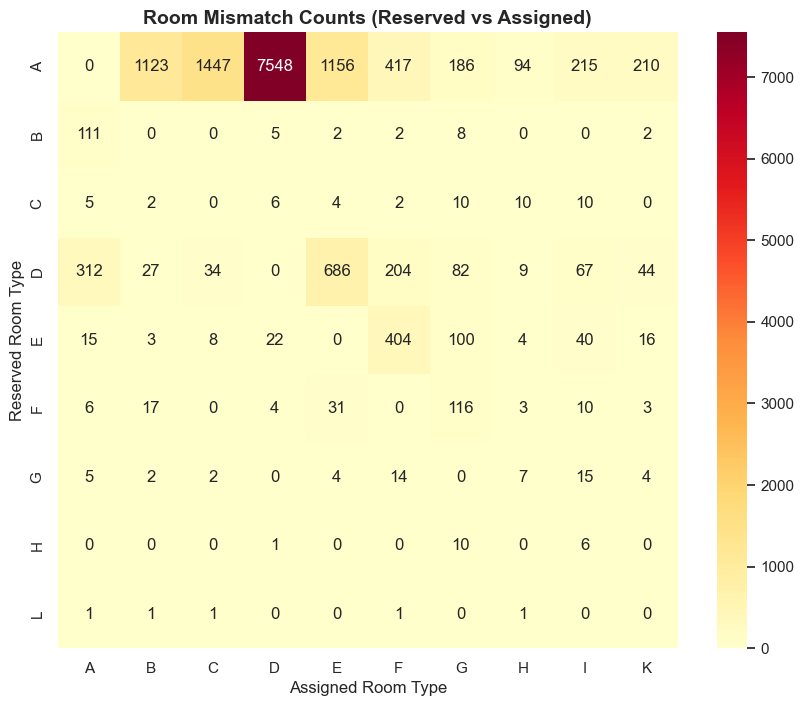

In [81]:
room_mismatch = df[df['reserved_room_type'] != df['assigned_room_type']]
mismatch_cancel_rate = pd.crosstab(room_mismatch['reserved_room_type'], room_mismatch['assigned_room_type'])

plt.figure(figsize=(10, 8))
sns.heatmap(mismatch_cancel_rate, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Room Mismatch Counts (Reserved vs Assigned)', fontsize=14, weight='bold')
plt.xlabel('Assigned Room Type')
plt.ylabel('Reserved Room Type')
plt.show()

### 🛎️ 7. Market Segment vs. Cancellation Rate

Why: Certain segments like "Online TA" might have higher no-shows.

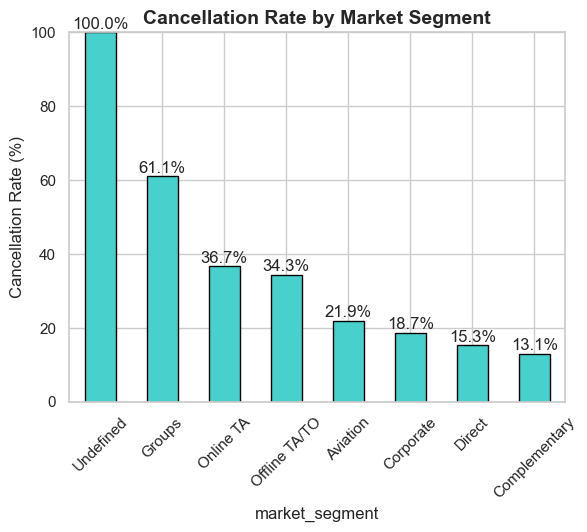

In [82]:
market_cancel = df.groupby('market_segment')['is_canceled'].mean() * 100
market_cancel = market_cancel.sort_values(ascending=False)

market_cancel.plot(kind='bar', color='mediumturquoise', edgecolor='black')
plt.title('Cancellation Rate by Market Segment', fontsize=14, weight='bold')
plt.ylabel('Cancellation Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)

for index, value in enumerate(market_cancel):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.show()


### 🧳 8. Special Requests vs. No-show Rate

Why: More special requests might indicate serious intent (lower no-show).

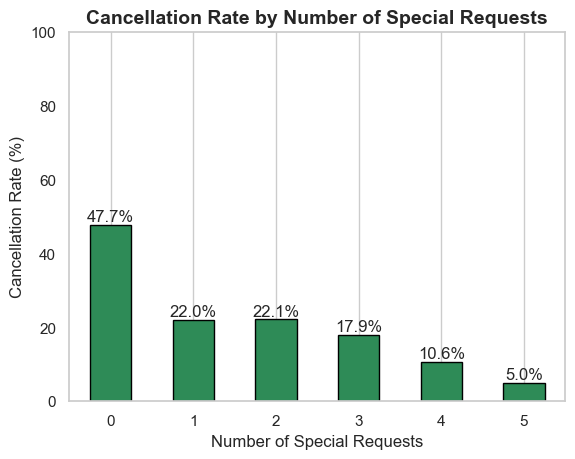

In [83]:
requests_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean() * 100

requests_cancel.plot(kind='bar', color='seagreen', 
                     edgecolor='black')
plt.title('Cancellation Rate by Number of Special Requests', 
          fontsize=14, weight='bold')
plt.xlabel('Number of Special Requests')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=0)

# Add percentage labels on top of bars
for index, value in enumerate(requests_cancel):
    plt.text(index, value + 1, f'{value:.1f}%', ha='center')

plt.grid(axis='y')
plt.show()


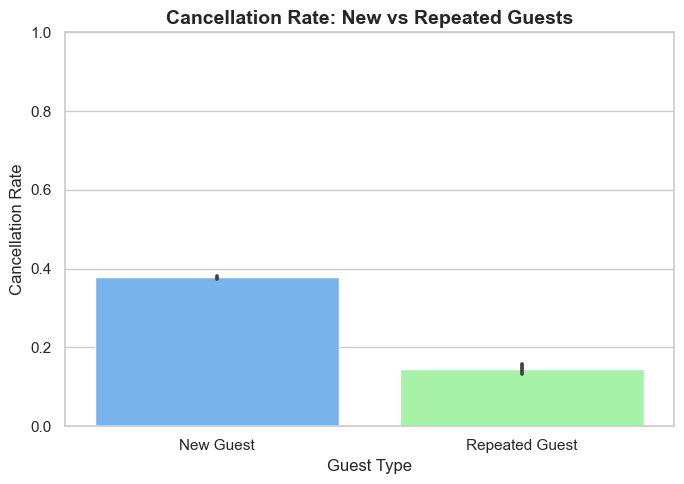

In [84]:
# Plot for cancellation rate: New vs Repeated guests
sns.set(style="whitegrid")

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x='is_repeated_guest',
    y='is_canceled',
    data=df,
    estimator=lambda x: sum(x)/len(x),
    palette=['#66b3ff', '#99ff99']
)

ax.set_xticklabels(['New Guest', 'Repeated Guest'])
ax.set_title('Cancellation Rate: New vs Repeated Guests', fontsize=14, weight='bold')
ax.set_ylabel('Cancellation Rate', fontsize=12)
ax.set_xlabel('Guest Type', fontsize=12)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

<Axes: >

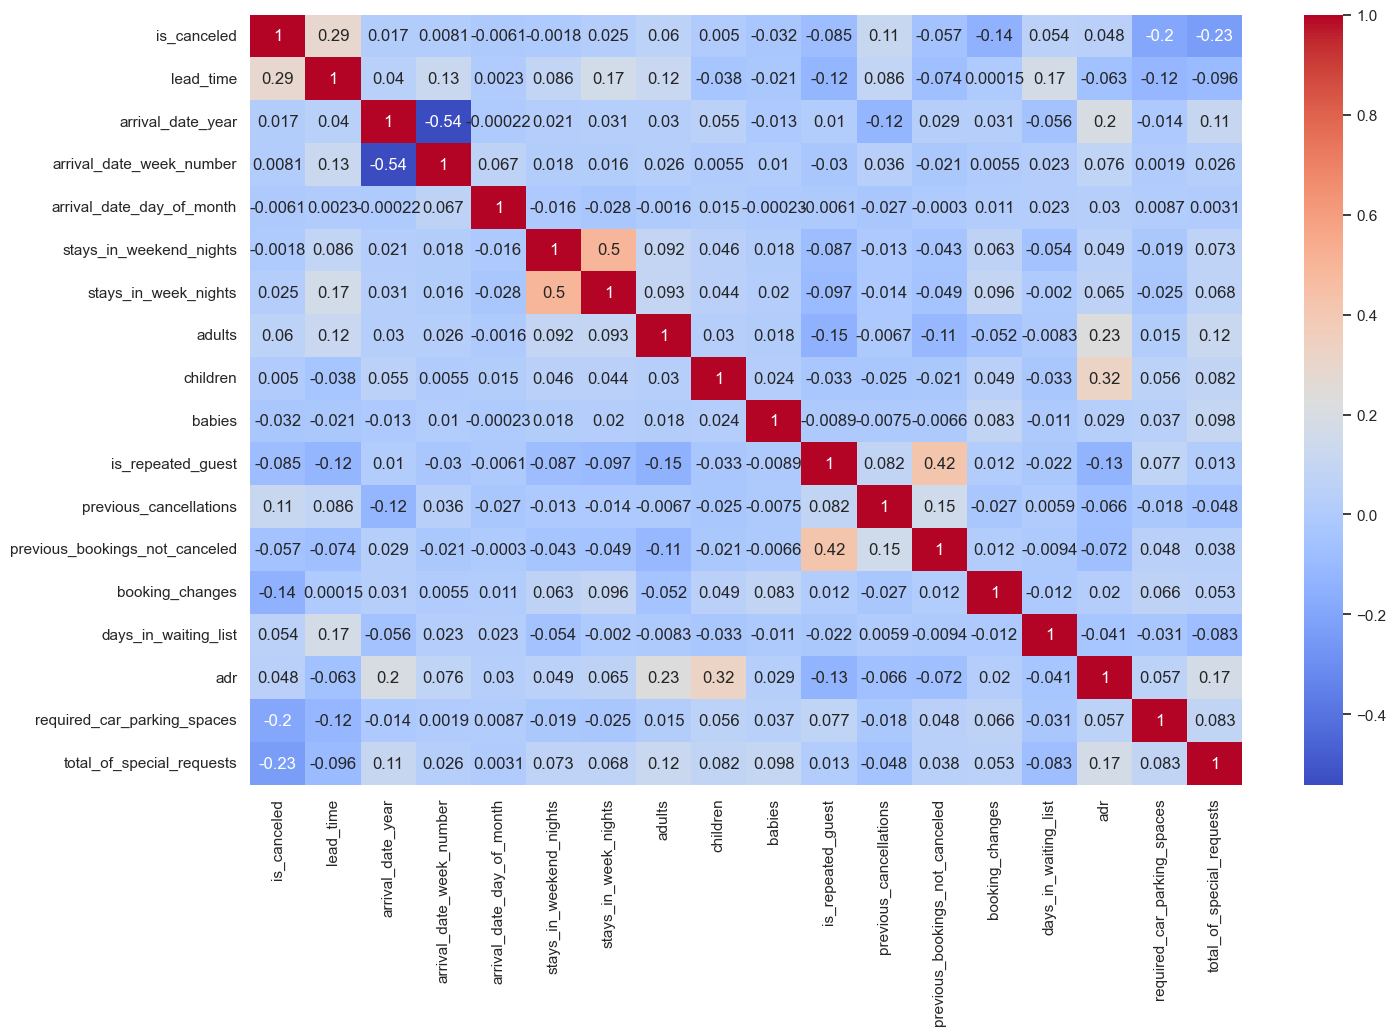

In [85]:
# Heating map showing the correlation between the numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

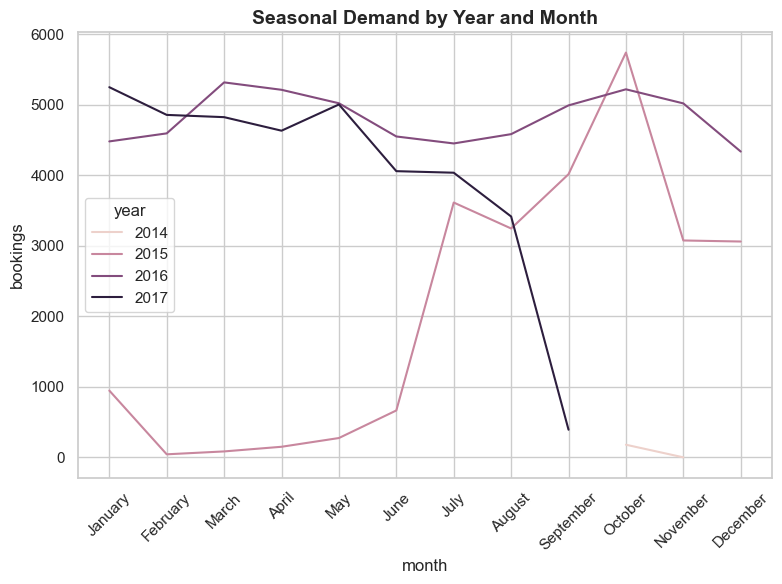

In [86]:
# Convert to datetime format
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], errors='coerce')

# Set plot style
sns.set(style="whitegrid")

# Show seasonal demand - Line plot by year and month
df['year'] = df['reservation_status_date'].dt.year
df['month'] = df['reservation_status_date'].dt.month_name()
monthly_demand = df.groupby(['year', 'month']).size().reset_index(name='bookings')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_demand['month'] = pd.Categorical(monthly_demand['month'], categories=month_order, ordered=True)

plt.figure(figsize=(8, 6))
sns.lineplot(data=monthly_demand.sort_values('month'), x='month', y='bookings', hue='year')
plt.title('Seasonal Demand by Year and Month', fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

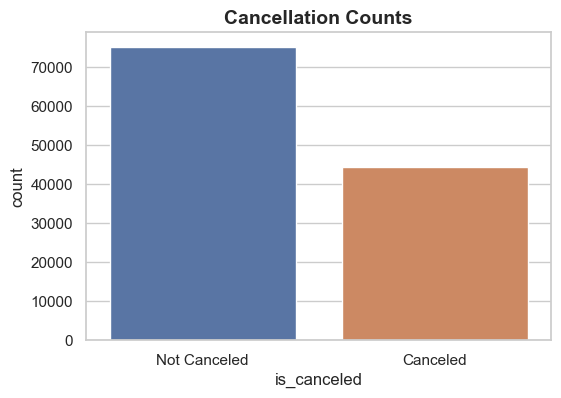

In [87]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_canceled')
plt.title('Cancellation Counts', fontsize=14, weight='bold')
plt.xticks([0, 1], ['Not Canceled', 'Canceled'])
plt.show()

C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


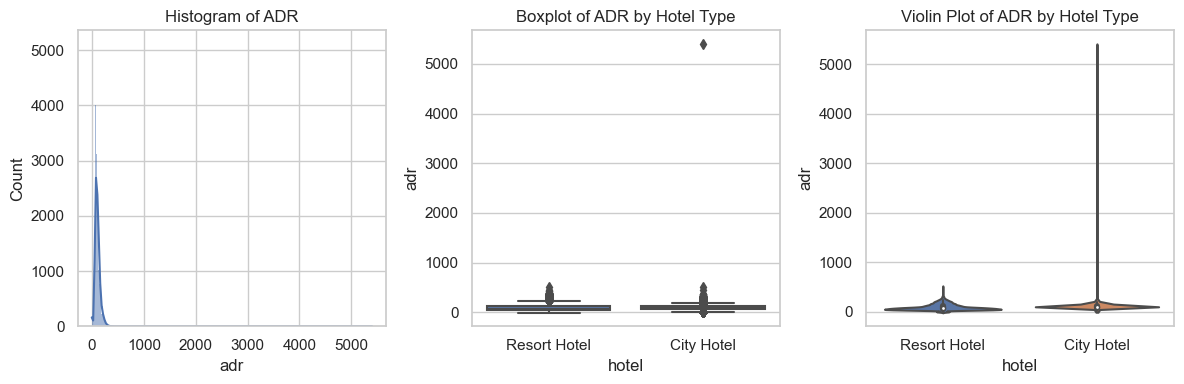

In [88]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['adr'], kde=True)
plt.title('Histogram of ADR')

plt.subplot(1, 3, 2)
sns.boxplot(x='hotel', y='adr', data=df)
plt.title('Boxplot of ADR by Hotel Type')

plt.subplot(1, 3, 3)
sns.violinplot(x='hotel', y='adr', data=df)
plt.title('Violin Plot of ADR by Hotel Type')
plt.tight_layout()
plt.show()

In [89]:
# Correlation with target variable
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.293123
previous_cancellations            0.110133
adults                            0.060017
days_in_waiting_list              0.054186
adr                               0.047557
stays_in_week_nights              0.024765
arrival_date_year                 0.016660
arrival_date_week_number          0.008148
children                          0.005036
stays_in_weekend_nights          -0.001791
arrival_date_day_of_month        -0.006130
babies                           -0.032491
previous_bookings_not_canceled   -0.057358
is_repeated_guest                -0.084793
booking_changes                  -0.144381
required_car_parking_spaces      -0.195498
total_of_special_requests        -0.234658
Name: is_canceled, dtype: float64

In [90]:
# # Heating map showing the correlation between the numeric columns
# numeric_df = df.select_dtypes(include=['float64', 'int64'])
# corr_matrix = numeric_df.corr()
# plt.figure(figsize=(20, 10))
# sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

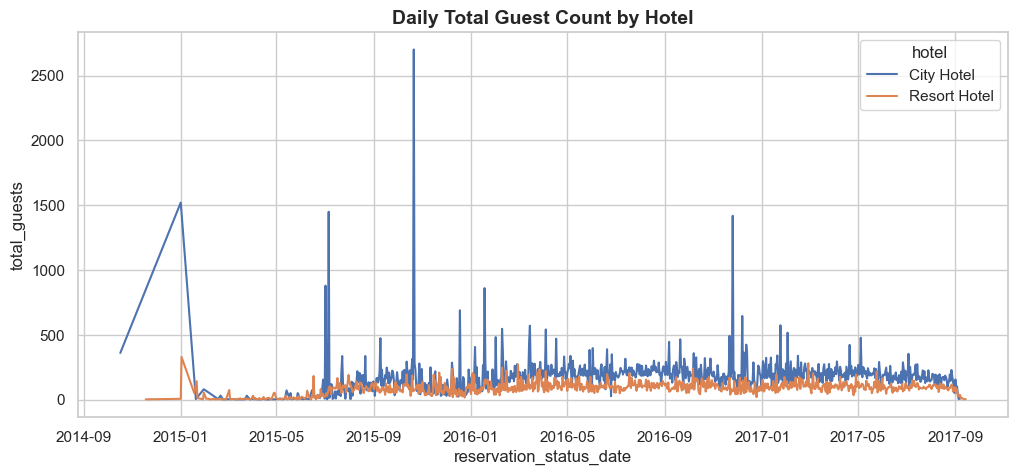

In [91]:
# 5. Visualize overbooking - Line plot (demand vs capacity), Stacked bar
# Estimating overbooking by rooms: Assume "hotel" + "arrival_date" defines a room capacity scenario
daily_bookings = df.groupby(['reservation_status_date', 'hotel']).agg({'adults': 'sum', 'children': 'sum', 'babies': 'sum'}).reset_index()
daily_bookings['total_guests'] = daily_bookings['adults'] + daily_bookings['children'] + daily_bookings['babies']

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_bookings, x='reservation_status_date', y='total_guests', hue='hotel')
plt.title('Daily Total Guest Count by Hotel', fontsize=14, weight='bold')
plt.show()

# check outliers

C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\charl\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a len

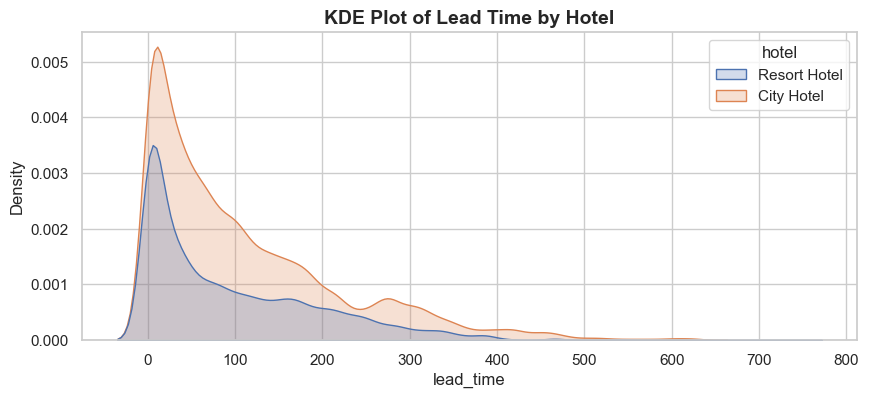

In [92]:
# 6. Compare distributions - KDE plot, Boxplot
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='lead_time', hue='hotel', fill=True)
plt.title('KDE Plot of Lead Time by Hotel', fontsize=14, weight='bold')
plt.show()

# Feature selection

In [93]:
selected_features = ['lead_time', 'booking_changes','previous_cancellations', 'total_of_special_requests',
                     'required_car_parking_spaces', 'is_repeated_guest', 'adults']


# Random Forest Implementation

In [94]:
X = df[selected_features]
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [95]:
# Initialize and train a Random Forest classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [96]:
# predict
y_pred = rf_model.predict(X_test)

In [97]:
# Evaluation
conf_matrix = confusion_matrix(y_test, y_pred)

In [98]:
print(conf_matrix)

[[12886  2021]
 [ 3652  5319]]


## Results

In [99]:
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.78      0.86      0.82     14907
           1       0.72      0.59      0.65      8971

    accuracy                           0.76     23878
   macro avg       0.75      0.73      0.74     23878
weighted avg       0.76      0.76      0.76     23878



# _this part is not done, It is a option for the future_

In [100]:
# identifying  the categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", cat_cols)

Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'adr_range', 'month']


In [101]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 34 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119390 non-null  object        
 1   is_canceled                     119390 non-null  int64         
 2   lead_time                       119390 non-null  int64         
 3   arrival_date_year               119390 non-null  int64         
 4   arrival_date_month              119390 non-null  object        
 5   arrival_date_week_number        119390 non-null  int64         
 6   arrival_date_day_of_month       119390 non-null  int64         
 7   stays_in_weekend_nights         119390 non-null  int64         
 8   stays_in_week_nights            119390 non-null  int64         
 9   adults                          119390 non-null  int64         
 10  children                        119390 non-null  float64

In [103]:
# Label encoding for "country", 'assigned_room_type' and 'reserved_room_type'
label_enc_cols = ['reserved_room_type', 'assigned_room_type', 'country']
le = LabelEncoder()

for col in label_enc_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [104]:
# combaning both methods
remaining_cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 75 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   is_canceled                     119390 non-null  int64         
 1   lead_time                       119390 non-null  int64         
 2   arrival_date_year               119390 non-null  int64         
 3   arrival_date_week_number        119390 non-null  int64         
 4   arrival_date_day_of_month       119390 non-null  int64         
 5   stays_in_weekend_nights         119390 non-null  int64         
 6   stays_in_week_nights            119390 non-null  int64         
 7   adults                          119390 non-null  int64         
 8   children                        119390 non-null  float64       
 9   babies                          119390 non-null  int64         
 10  country                         119390 non-null  int32  

In [106]:
# Correlation with target variable
# after the Label enconding and One-hot encoding
df.corr()['is_canceled'].sort_values(ascending=False)

is_canceled                     1.000000
deposit_type_Non Refund         0.481457
lead_time                       0.293123
country                         0.264738
market_segment_Groups           0.221859
                                  ...   
reservation_status_date        -0.165057
assigned_room_type             -0.176028
required_car_parking_spaces    -0.195498
total_of_special_requests      -0.234658
reservation_status_Check-Out   -1.000000
Name: is_canceled, Length: 75, dtype: float64

# PCA?